In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from matplotlib_venn import venn2  
from scipy import stats  
import os  
from matplotlib.lines import Line2D  
from matplotlib import rcParams  

# Create output directory for plots  
output_dir = '../comparison/2M_vs_4M'  
if not os.path.exists(output_dir):  
    os.makedirs(output_dir)  

In [2]:
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 10 
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  
rcParams['svg.fonttype'] = 'none'  
rcParams['figure.dpi'] = 300  

Merged data: 11955 genes

Hit counts by category:
Non-significant     11380
Screen2 Specific      393
Common Hit            169
Screen1 Specific       13
Name: hit_category, dtype: int64

Number of common hits: 169
Number of Screen1-specific hits: 13
Number of Screen2-specific hits: 393
Merged data: 11955 genes

Hit counts by category:
Non-significant     11688
Screen2 Specific      192
Common Hit             69
Screen1 Specific        6
Name: hit_category, dtype: int64

Number of common hits: 69
Number of Screen1-specific hits: 6
Number of Screen2-specific hits: 192
Merged data: 1529 genes

Hit counts by category:
Non-significant     1449
Screen2 Specific      55
Common Hit            22
Screen1 Specific       3
Name: hit_category, dtype: int64

Number of common hits: 22
Number of Screen1-specific hits: 3
Number of Screen2-specific hits: 55
Merged data: 1529 genes

Hit counts by category:
Non-significant     1364
Screen2 Specific      84
Common Hit            67
Screen1 Specific      

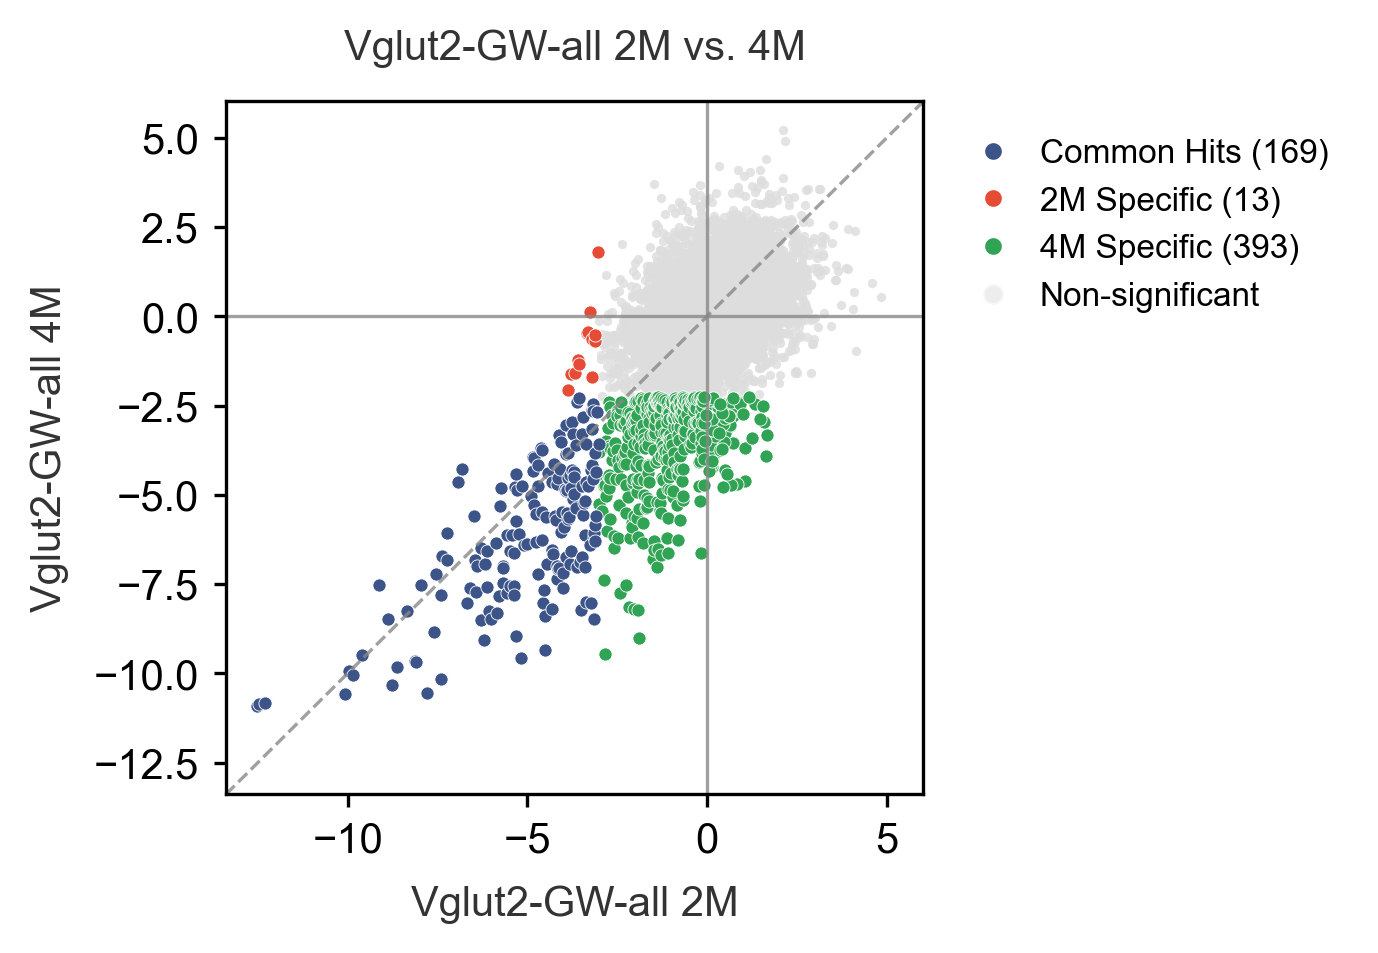

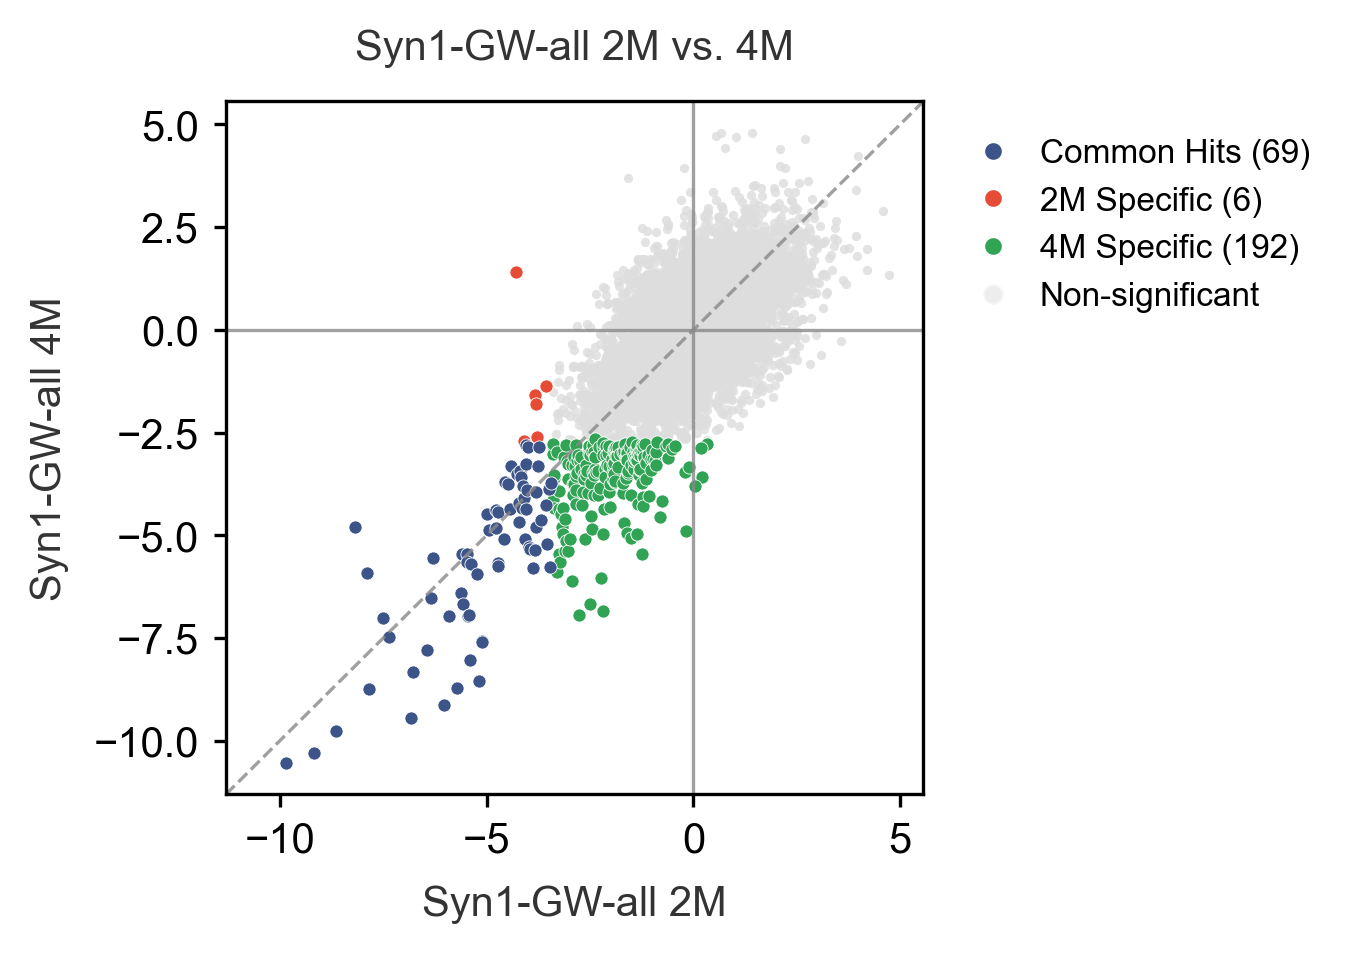

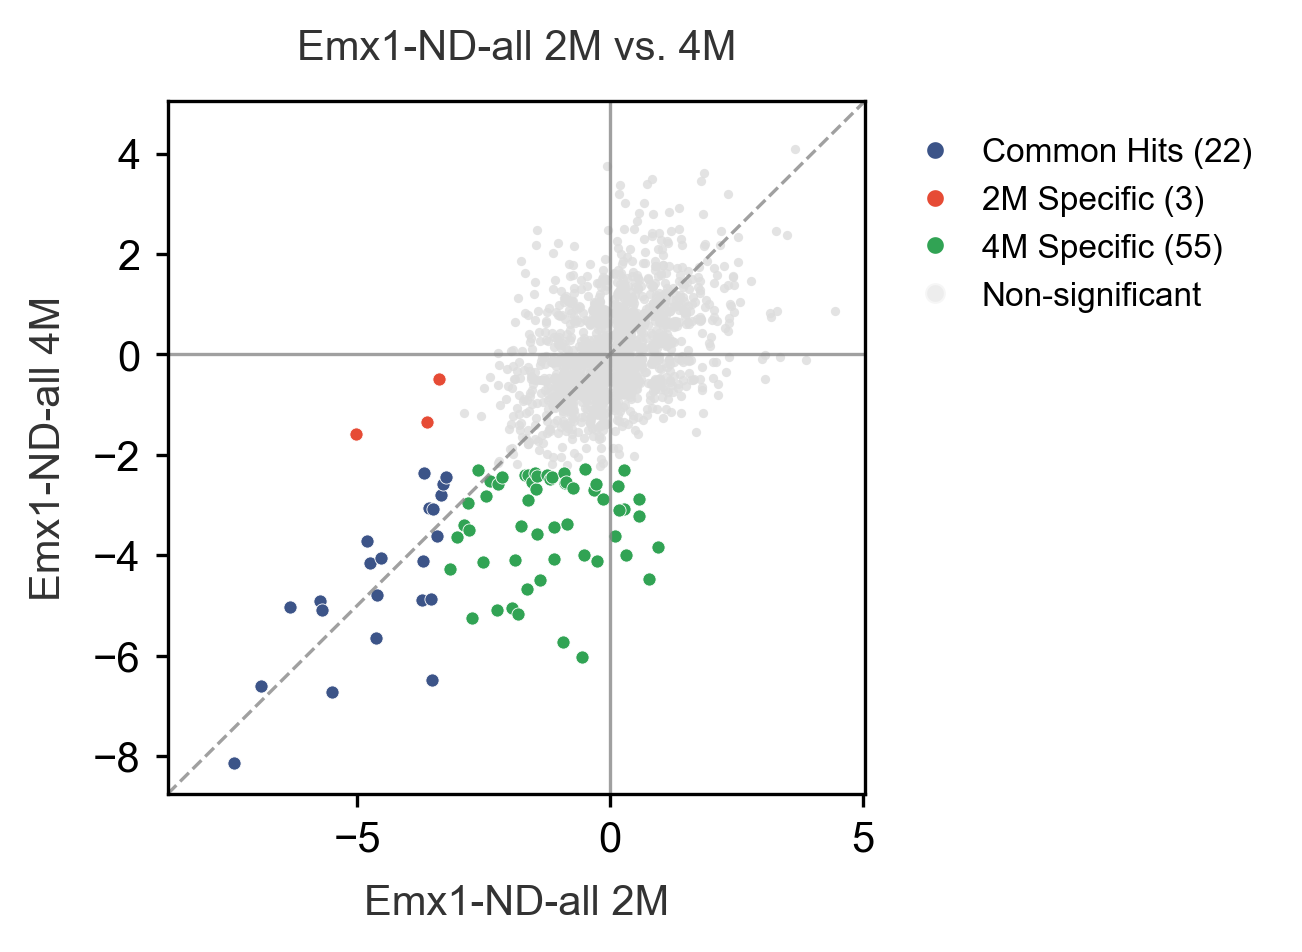

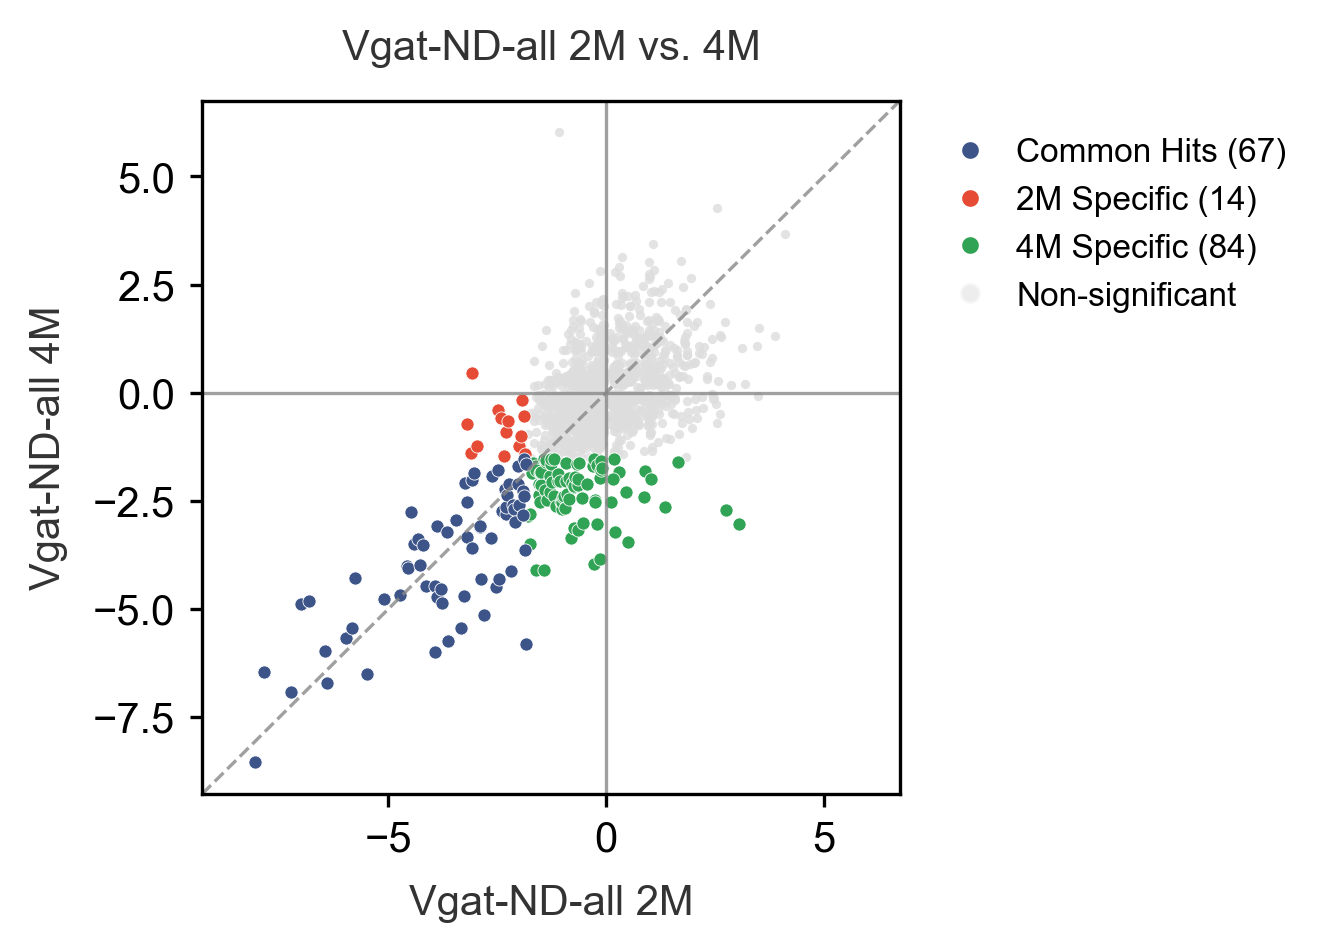

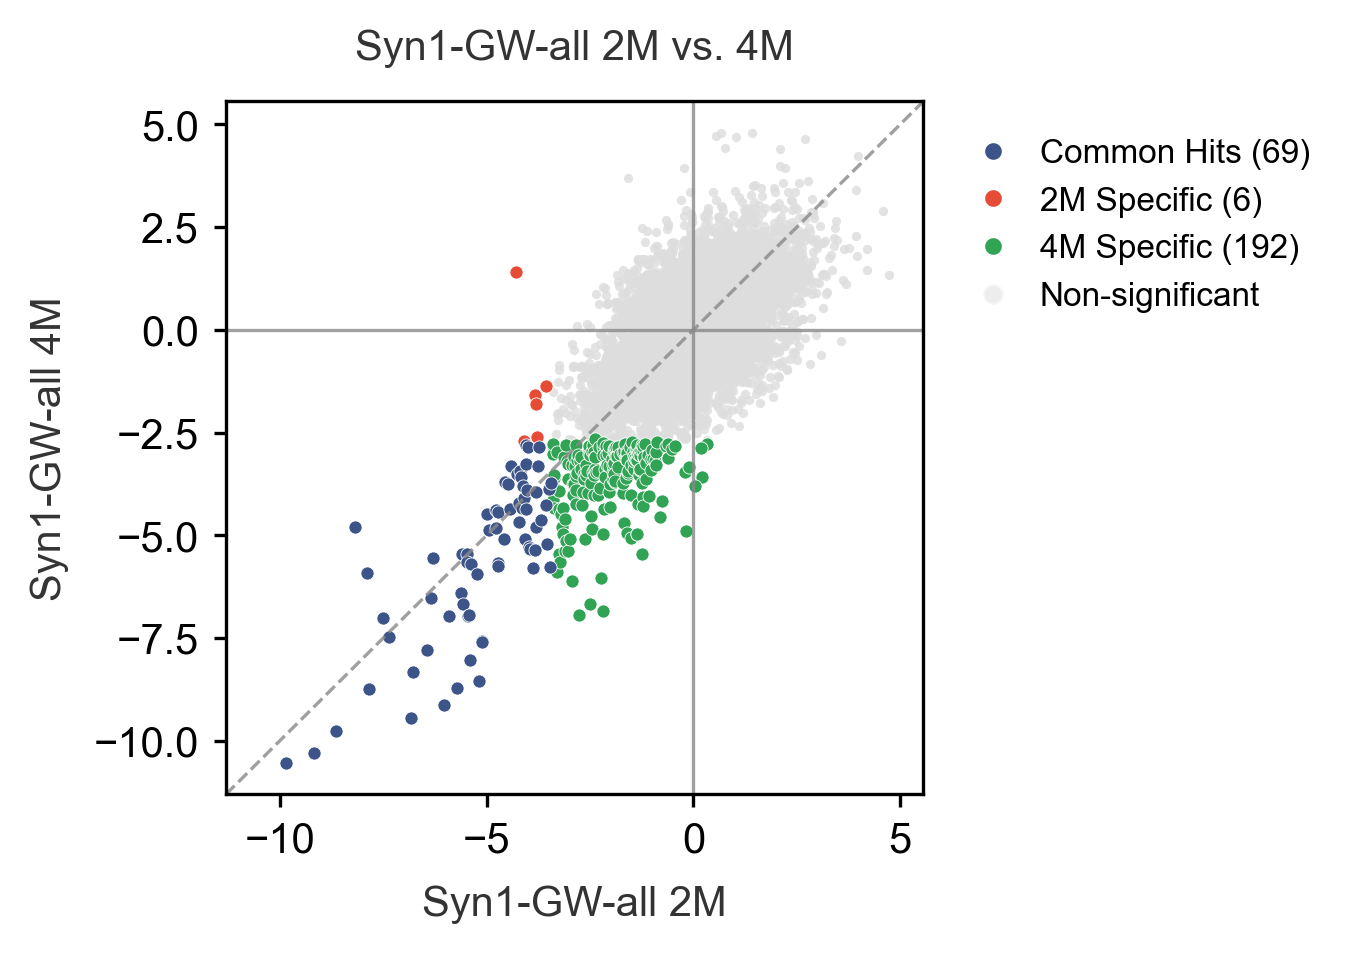

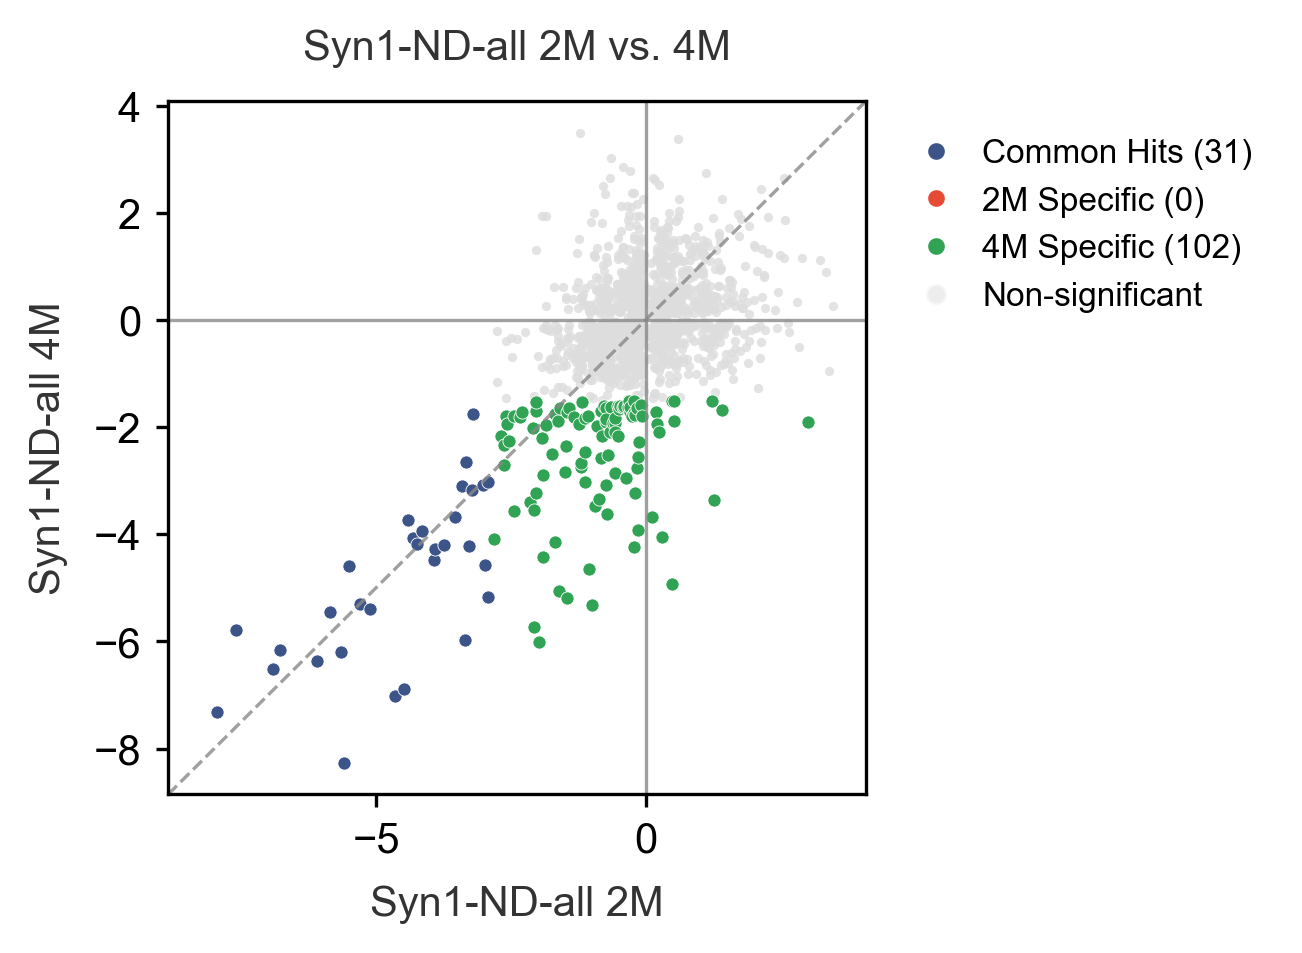

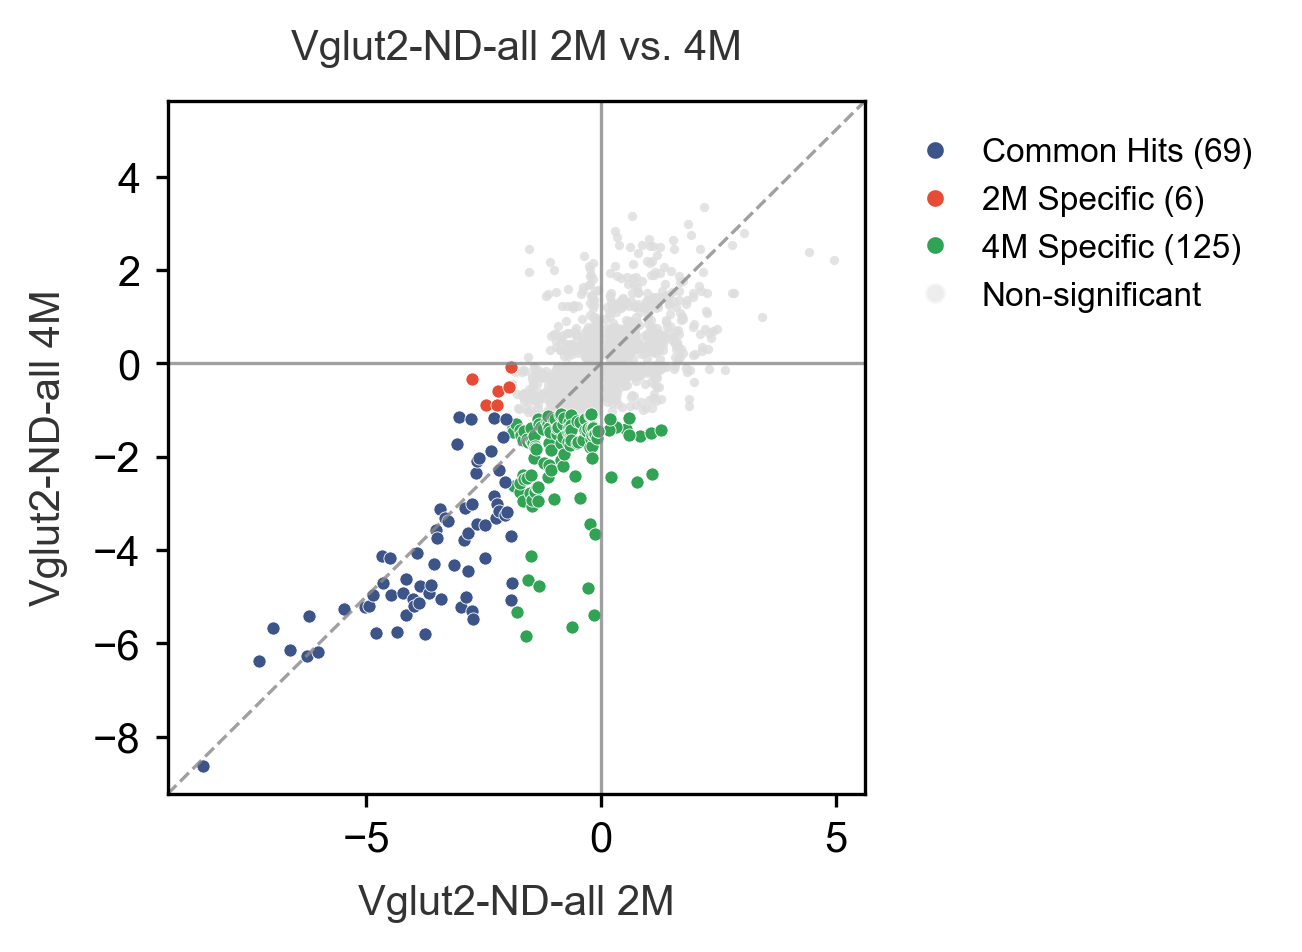

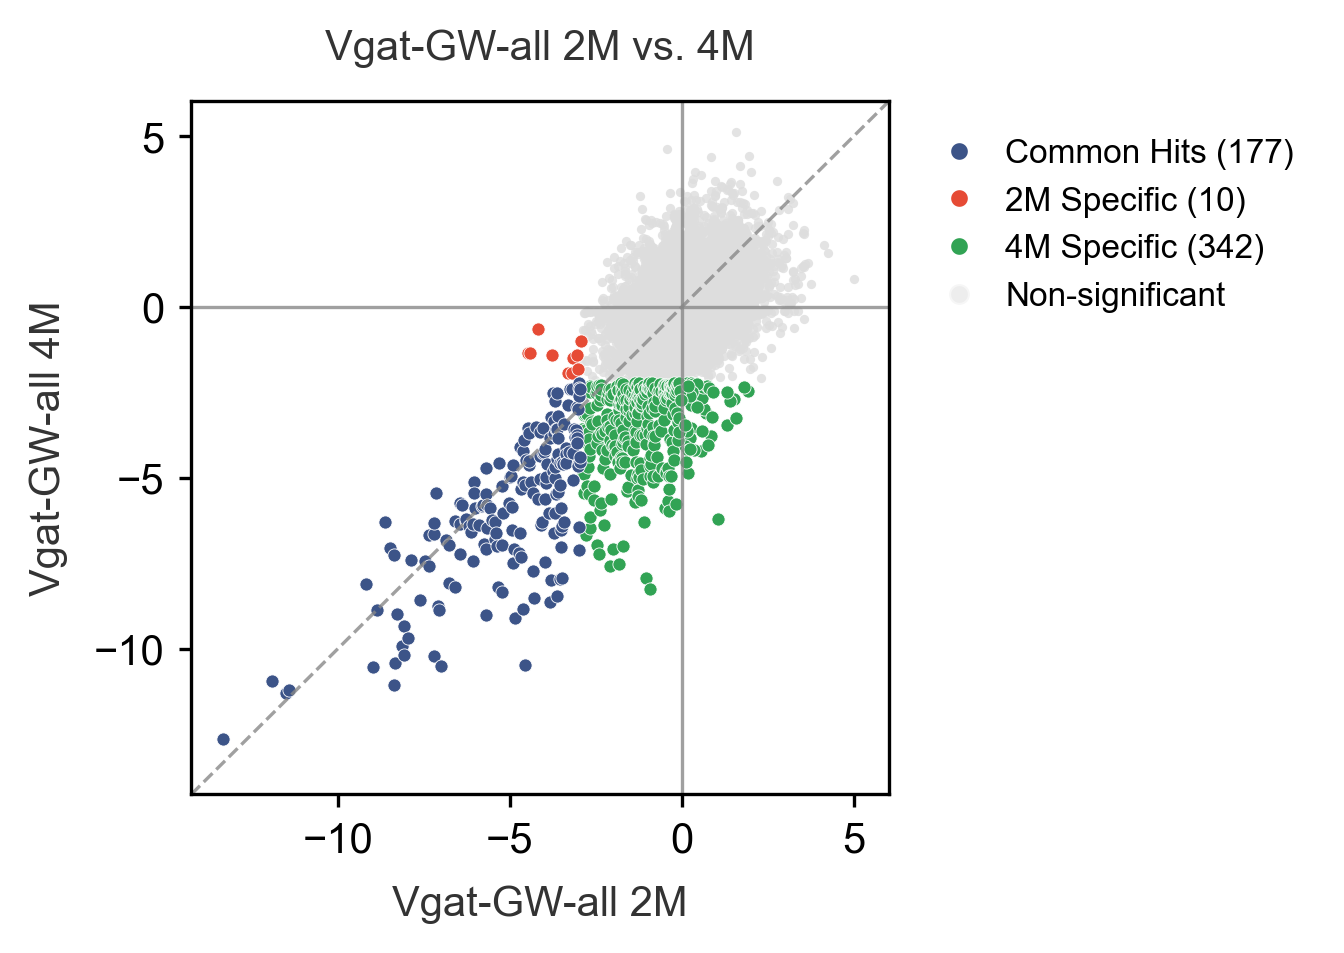

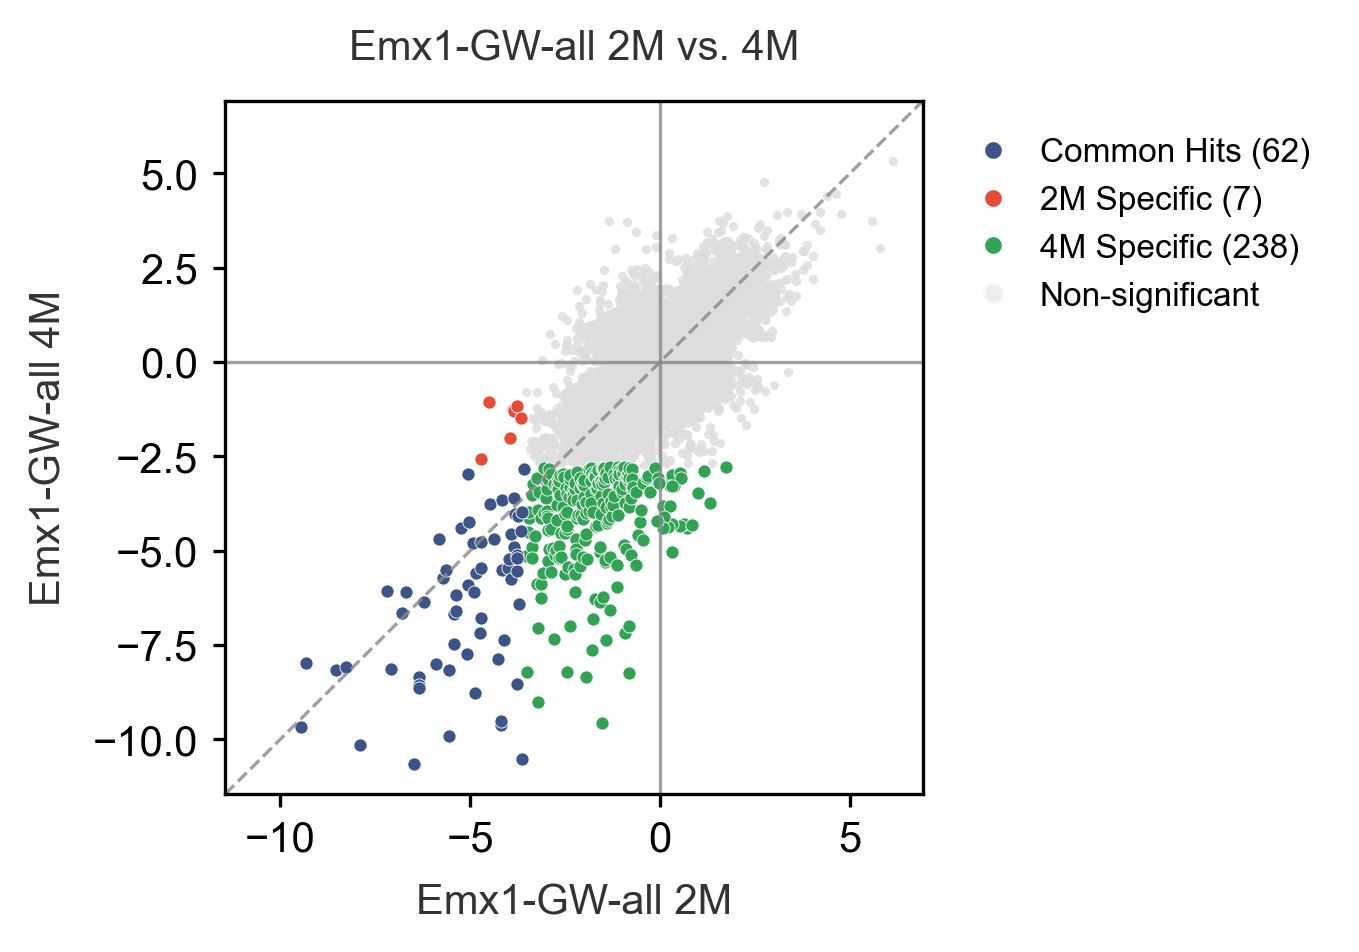

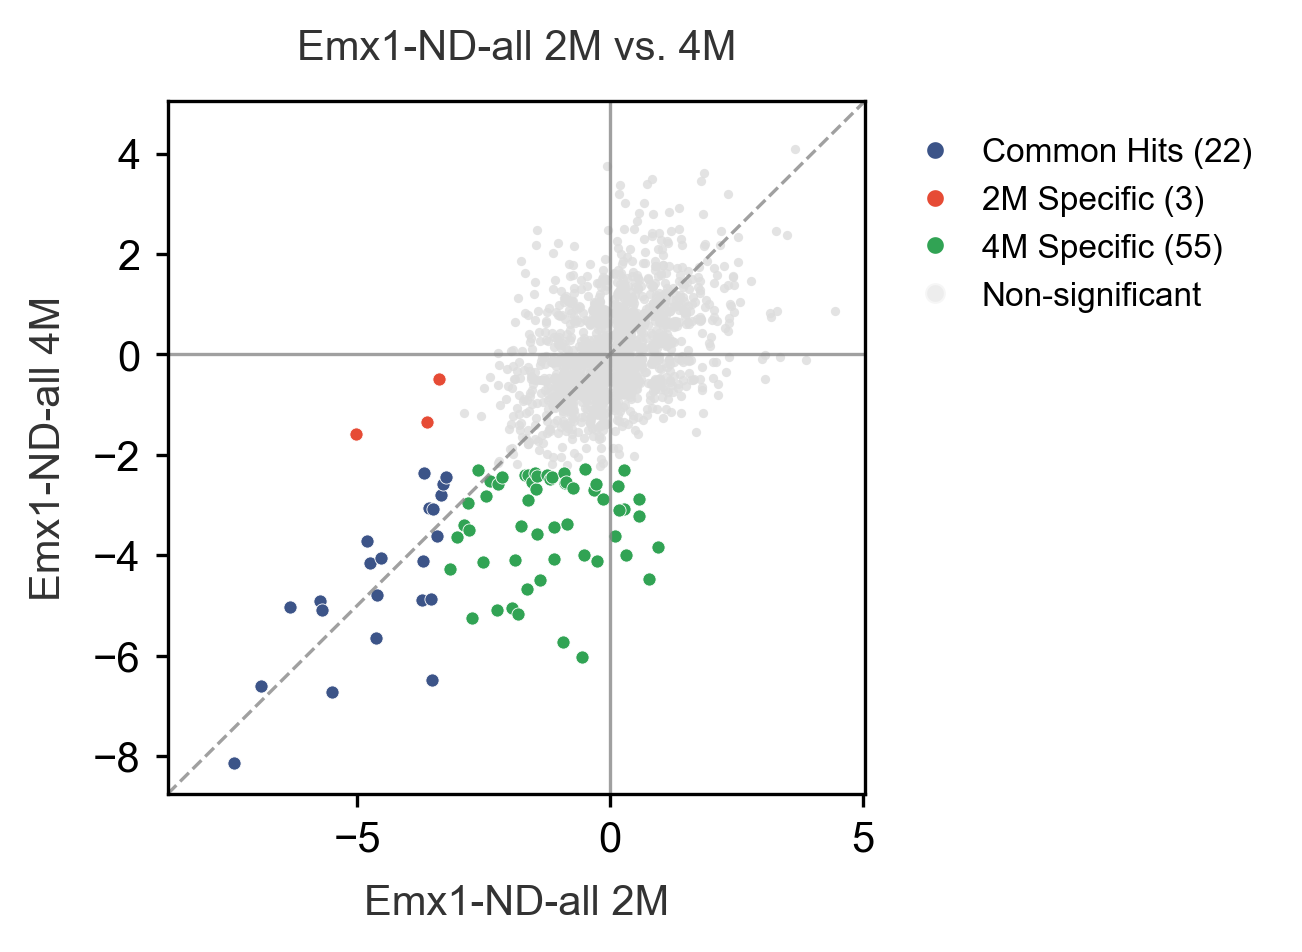

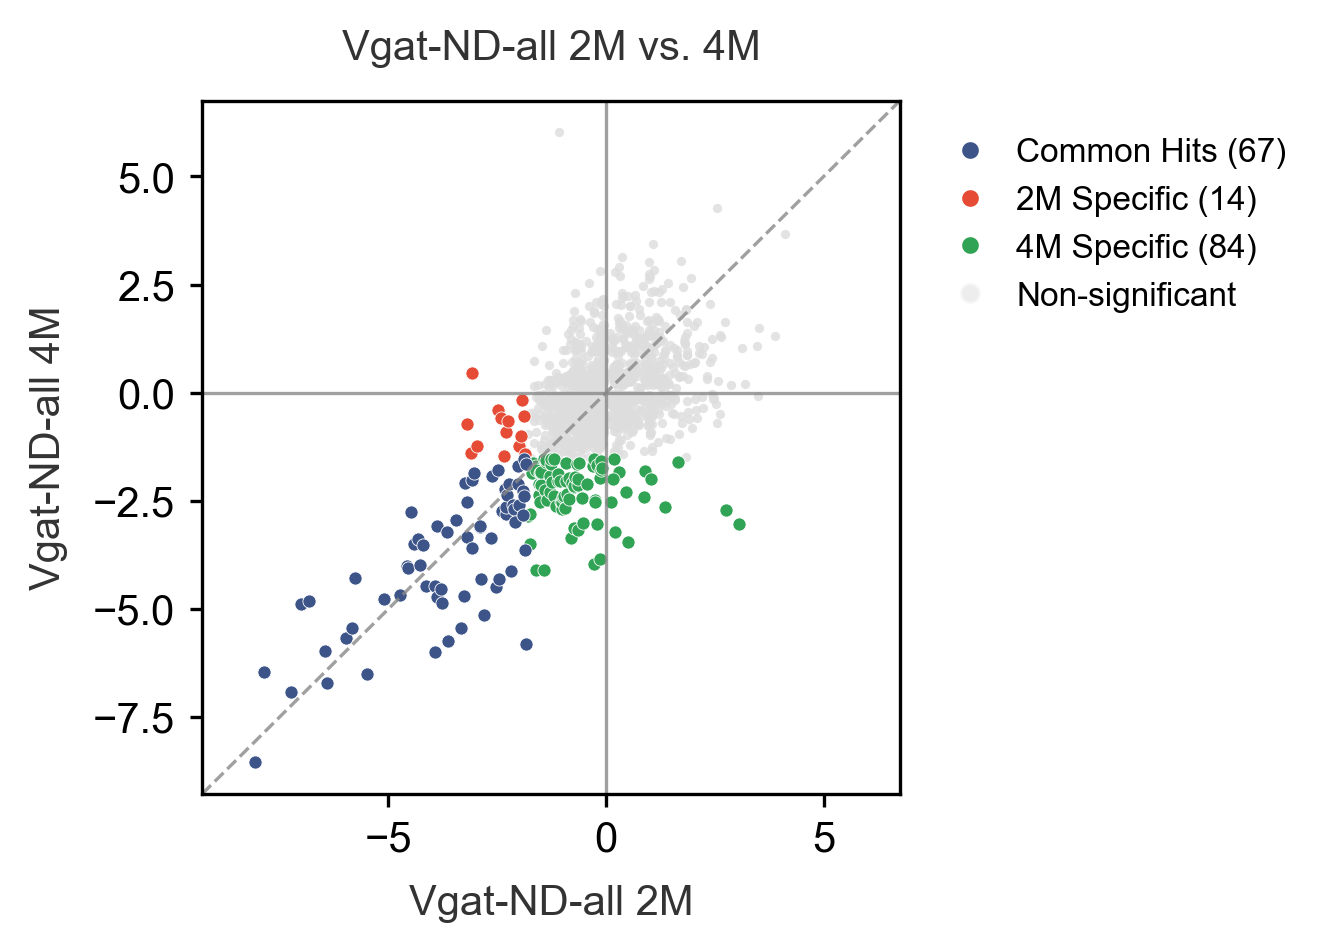

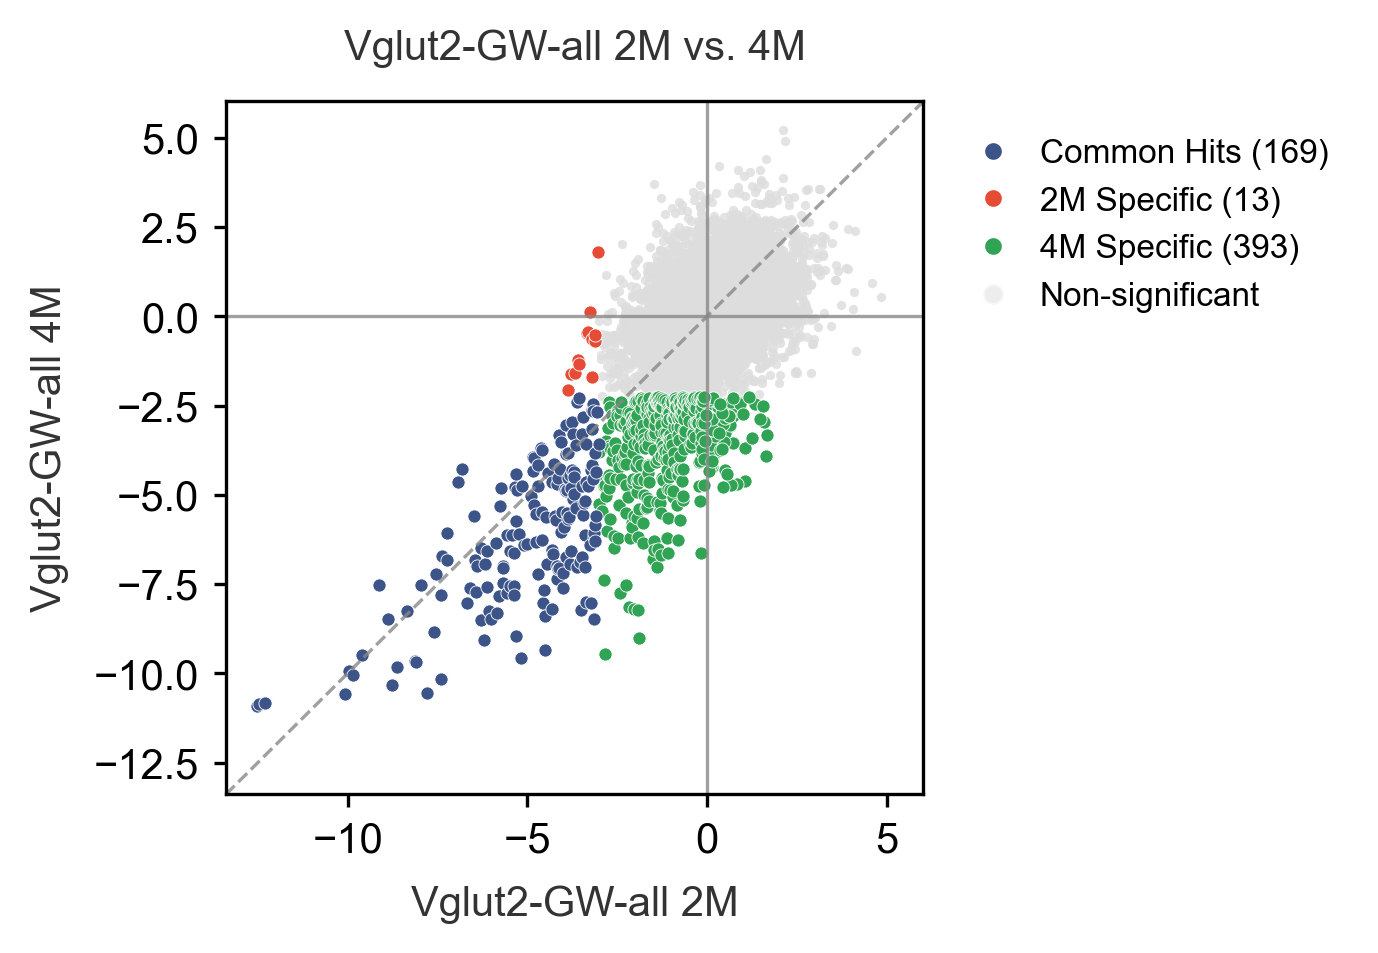

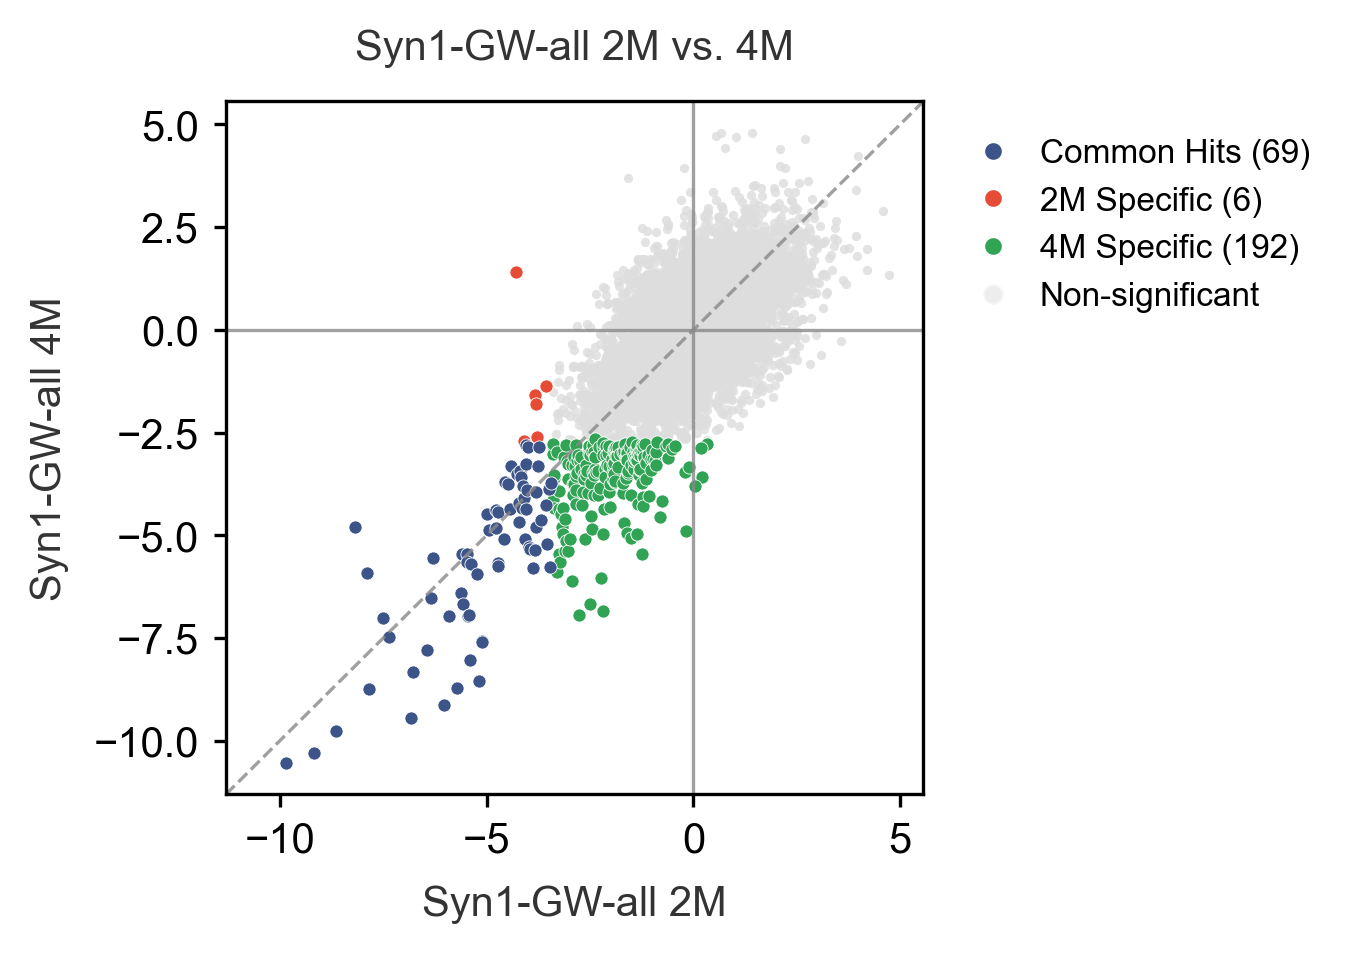

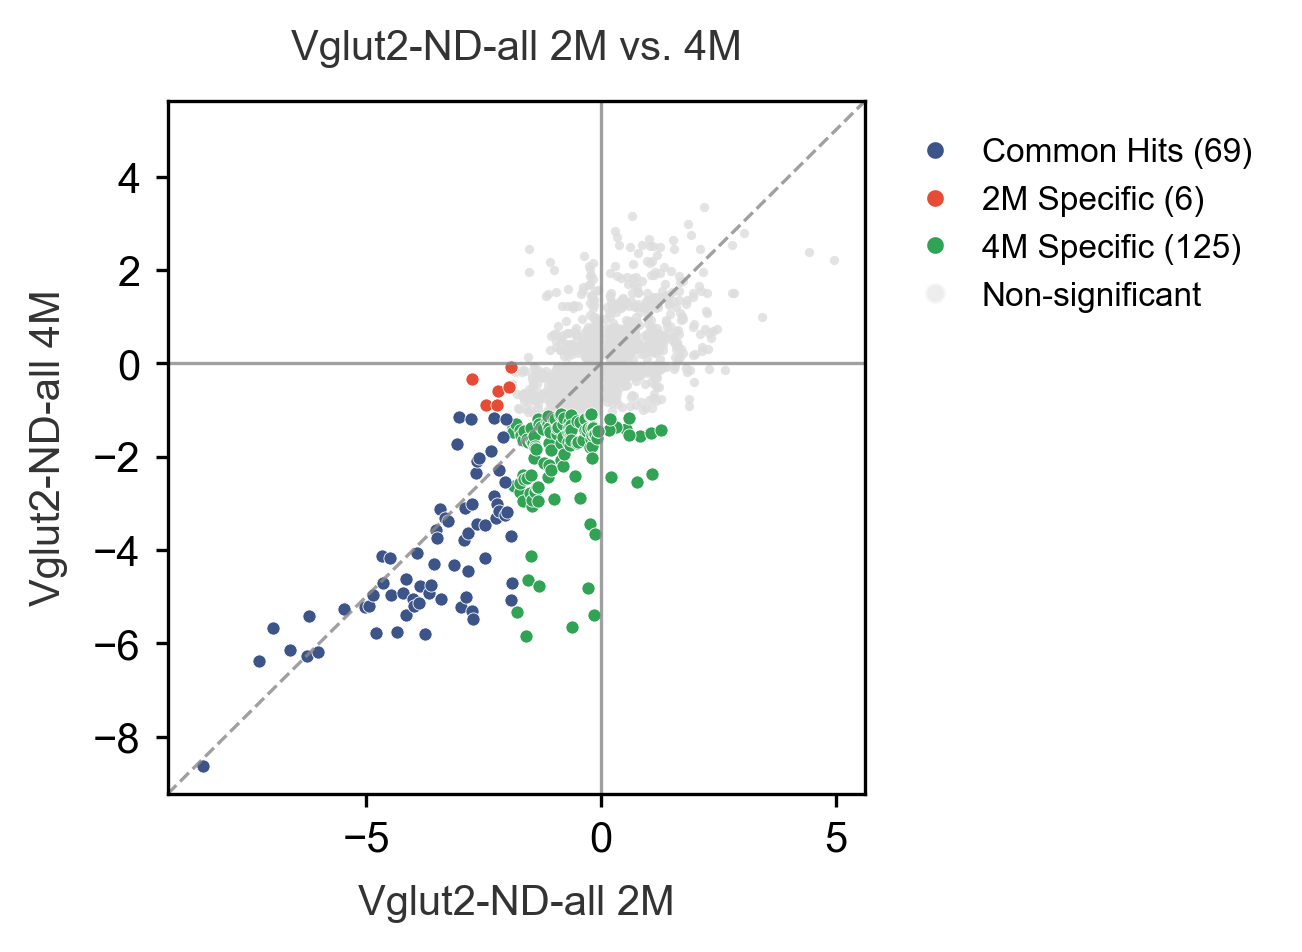

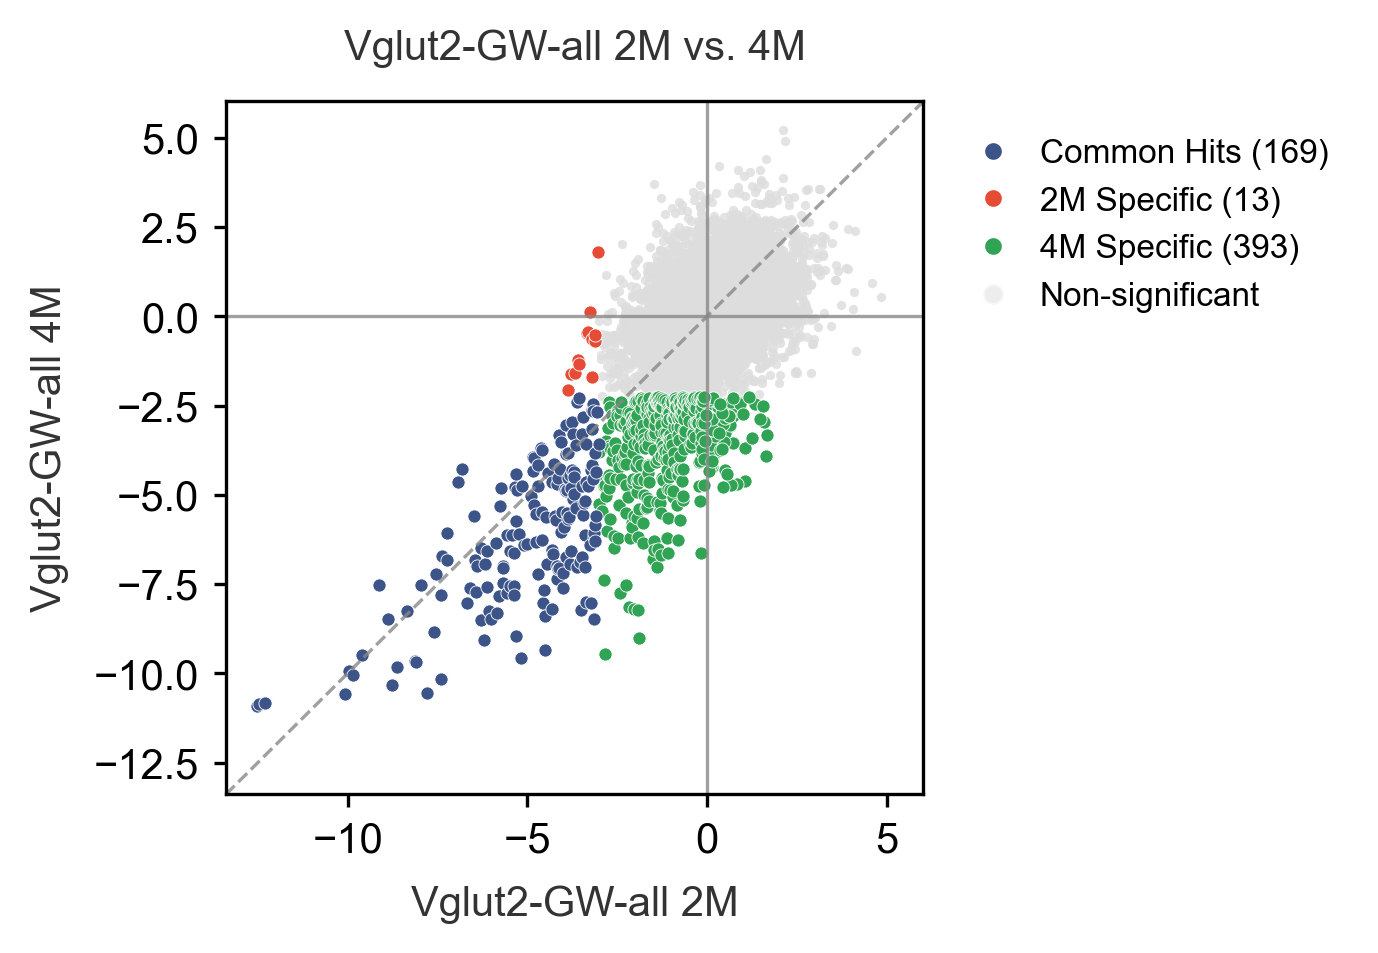

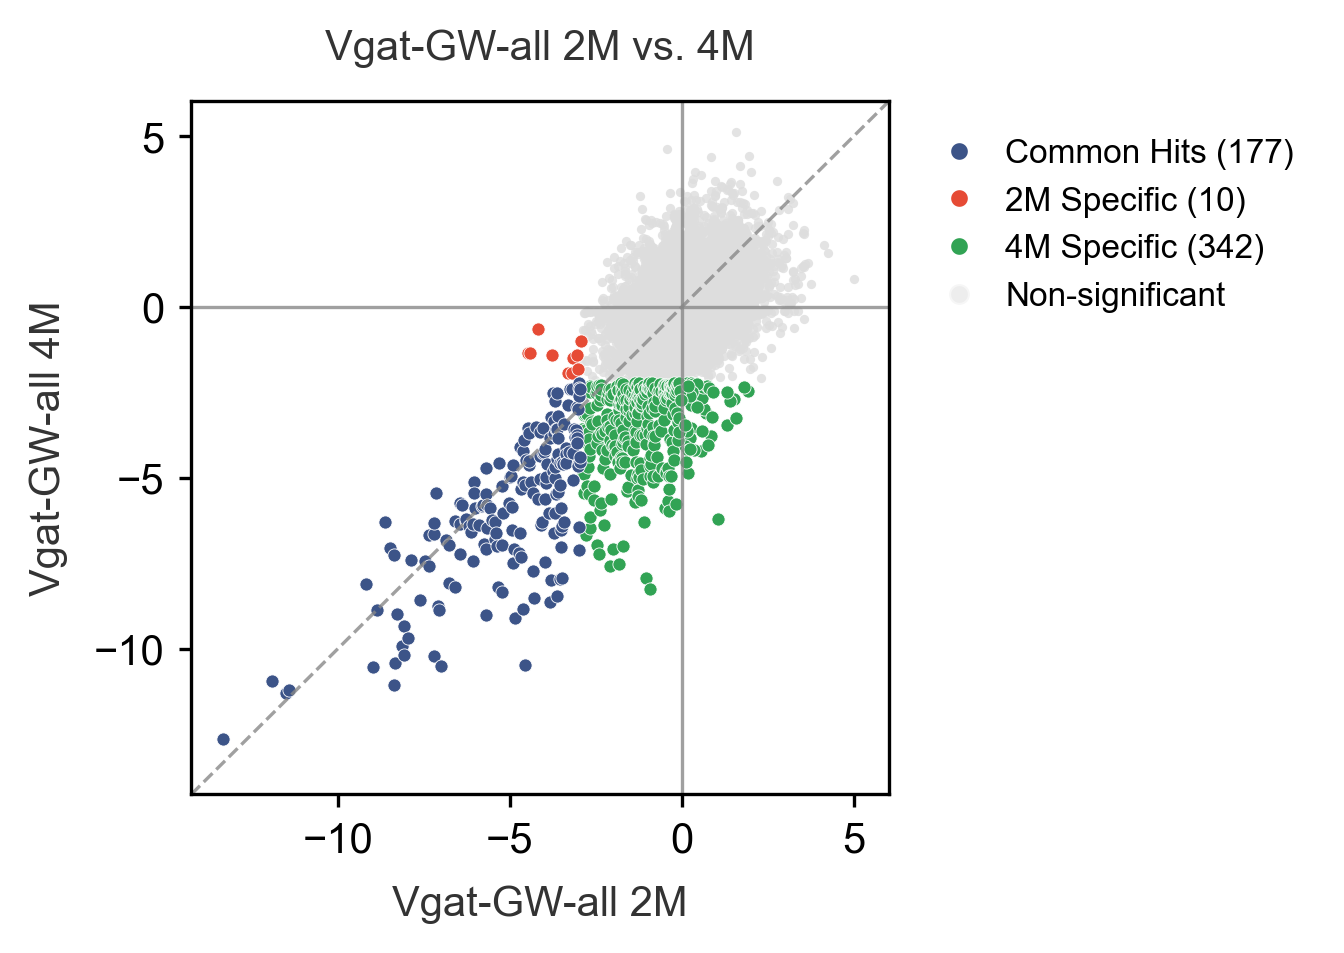

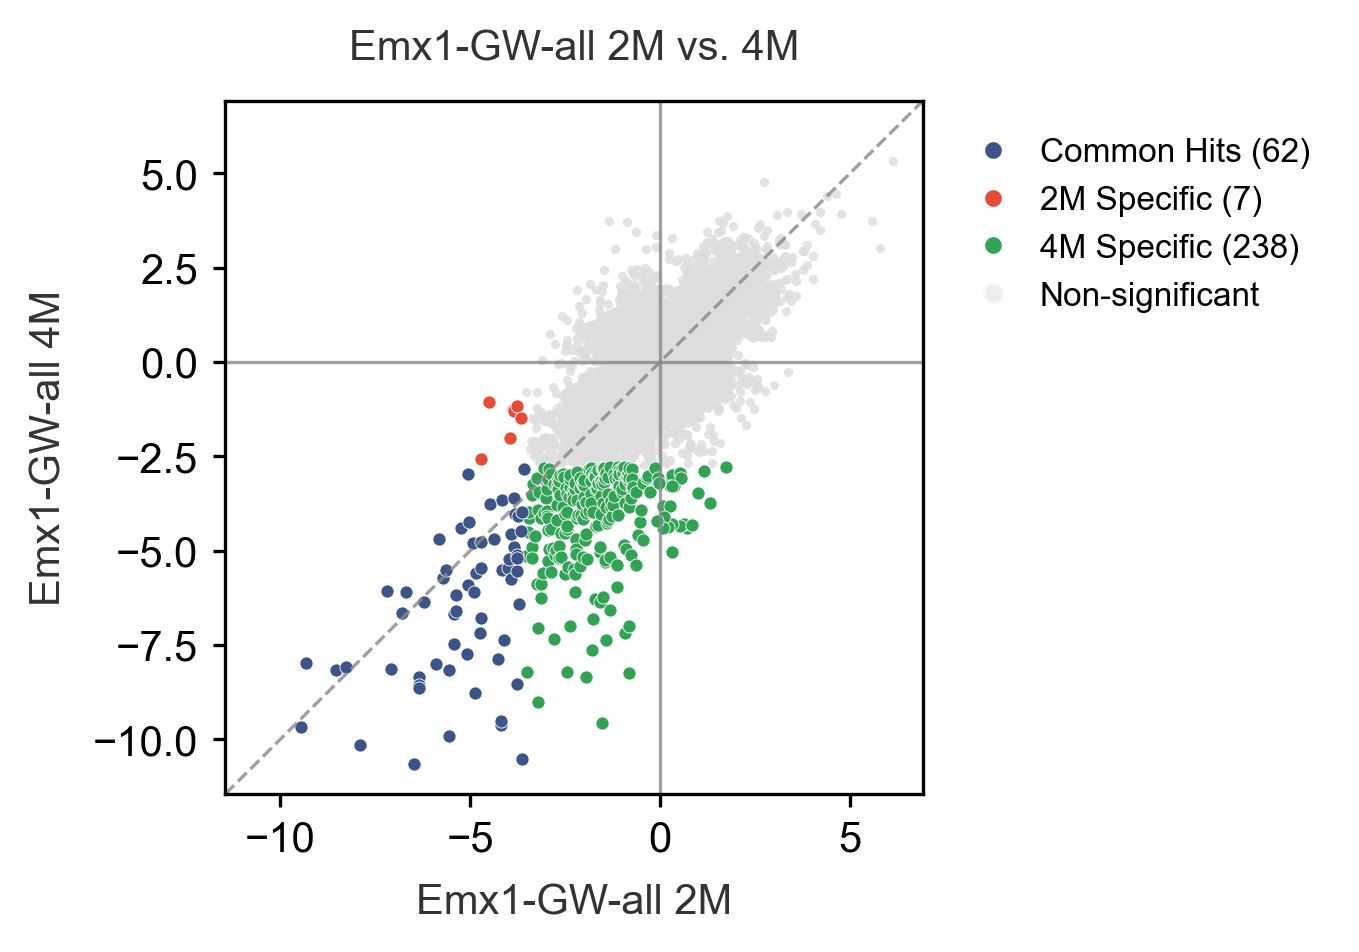

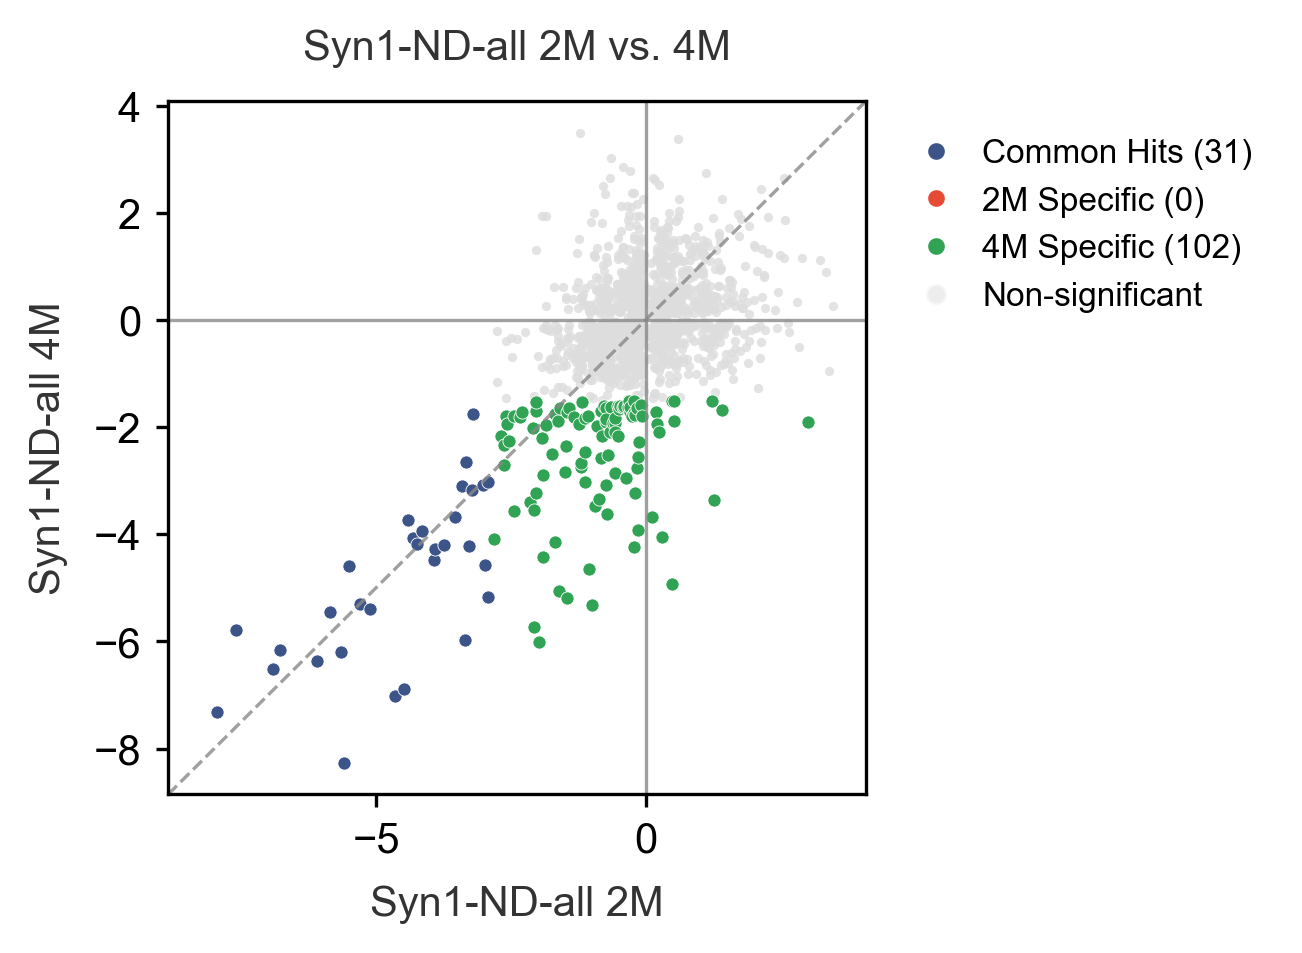

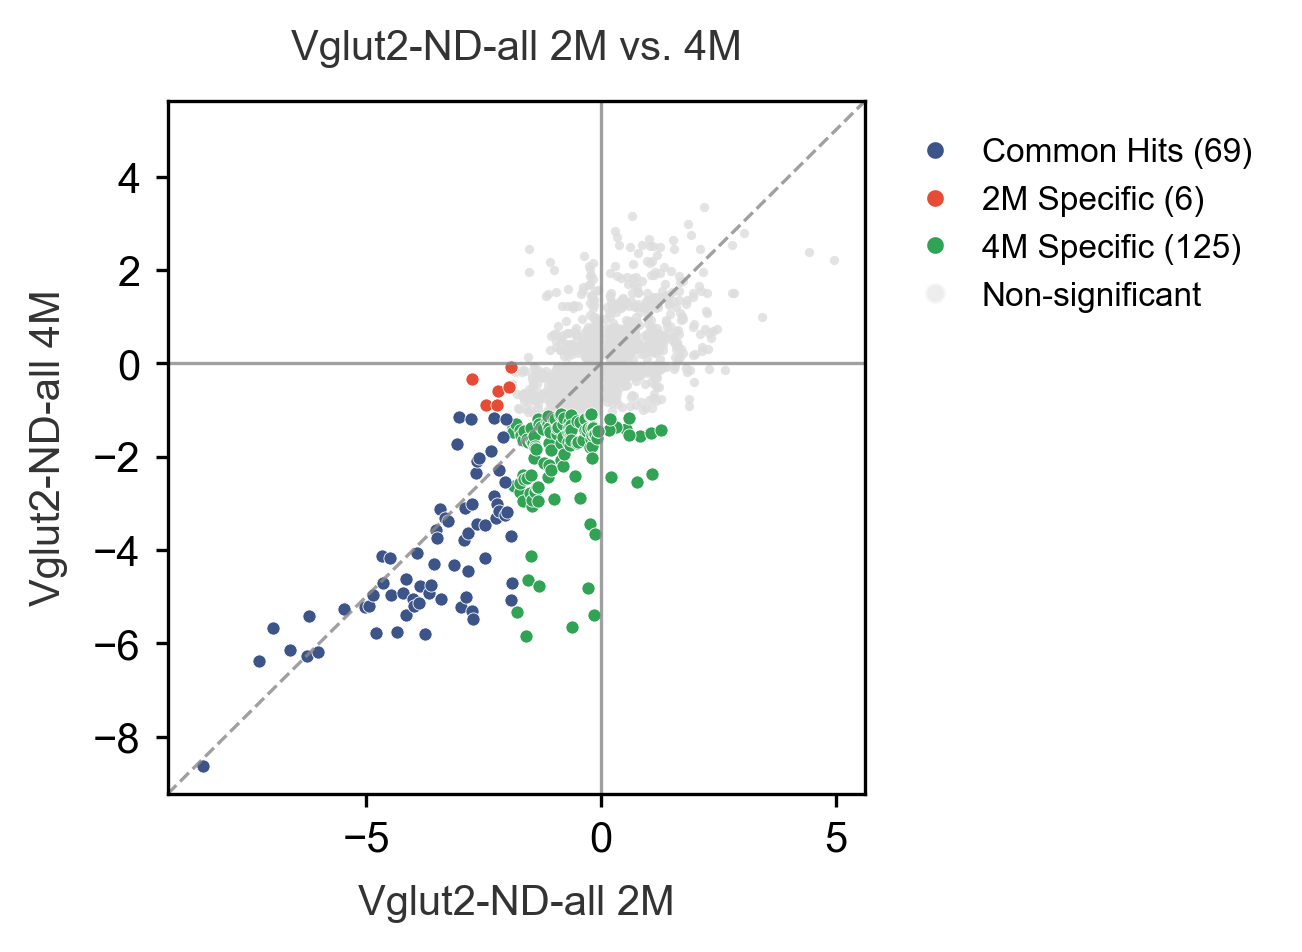

In [3]:
# Generate example data for two screens  
screens = [i.split('_')[0] for i in os.listdir('../new_mageck/') if not i.startswith('.')]
for screen in screens:
    m2_file = f'../new_mageck/{screen}_2M/{screen}_2M.gene_summary.txt'
    m4_file = f'../new_mageck/{screen}_4M/{screen}_4M.gene_summary.txt'
    df = pd.read_csv(m2_file, sep='\t', index_col=0)
    # gene_summary_path = f'../new_mageck/{sample}/{sample}.gene_summary.txt' 
    df['gene'] = [i.split('_')[0] for i in df.index.tolist()]
    df['signed_score'] = df.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)
    screen1_data = df


    df = pd.read_csv(m4_file,sep='\t', index_col=0)
    df['gene'] = [i.split('_')[0] for i in df.index.tolist()]
    df['signed_score'] = df.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)
    screen2_data = df


    # Merge datasets for comparison  
    merged_data = pd.merge(  
        screen1_data,   
        screen2_data,   
        left_index=True,
        right_index = True,  
        how='inner',   
        suffixes=('_screen1', '_screen2')  
    )  


    print(f"Merged data: {len(merged_data)} genes")  



    # Create hit categories for coloring  
    def categorize_hits(row):  
        sig1 = (row['neg|fdr_screen1']<0.1) & (row['neg|lfc_screen1']<0)
        sig2 = (row['neg|fdr_screen2']<0.1) & (row['neg|lfc_screen2']<0)
        if sig1 and sig2:  
            return "Common Hit"  
        elif sig1:  
            return "Screen1 Specific"  
        elif sig2:  
            return "Screen2 Specific"  
        else:  
            return "Non-significant"  

    merged_data['hit_category'] = merged_data.apply(categorize_hits, axis=1)  

    # Count hits by category  
    hit_counts = merged_data['hit_category'].value_counts()  
    print("\nHit counts by category:")  
    print(hit_counts)  


    # Create lists of hits for each category  
    common_hits = merged_data[merged_data['hit_category'] == "Common Hit"]['gene_screen1'].tolist()  
    screen1_specific = merged_data[merged_data['hit_category'] == "Screen1 Specific"]['gene_screen1'].tolist()  
    screen2_specific = merged_data[merged_data['hit_category'] == "Screen2 Specific"]['gene_screen1'].tolist()  

    print(f"\nNumber of common hits: {len(common_hits)}")  
    print(f"Number of Screen1-specific hits: {len(screen1_specific)}")  
    print(f"Number of Screen2-specific hits: {len(screen2_specific)}")  

    # Set up Cell-style colors - clean, distinctive but not overwhelming  
    category_colors = {  
        "Common Hit": "#3C5488FF",       # Cell red  
        "Screen1 Specific": "#E64B35", # Deep blue  
        "Screen2 Specific": "#31A354", # Forest green  
        "Non-significant": "#DDDDDD"   # Light gray  
    }  

    # Text color - Cell papers typically use dark gray instead of pure black  
    cell_text_color = "#333333"  

    # 1. Create LFC comparison scatter plot with Cell-style aesthetics  
    fig, ax = plt.figure(figsize=(3, 3), dpi=300), plt.gca()  

    # First plot all non-significant points (background)  
    nonsig_data = merged_data[merged_data['hit_category'] == "Non-significant"]  
    ax.scatter(  
        nonsig_data['signed_score_screen1'],   
        nonsig_data['signed_score_screen2'],  
        c=category_colors["Non-significant"],  
        alpha=0.8,  
        s=5,  
        linewidths=0,  
        rasterized=True  # Better for large datasets in PDF  
    )  

    # Then plot significant hits on top  
    for category in ["Screen1 Specific", "Screen2 Specific", "Common Hit"]:  
        cat_data = merged_data[merged_data['hit_category'] == category]  
        ax.scatter(  
            cat_data['signed_score_screen1'],   
            cat_data['signed_score_screen2'],  
            c=category_colors[category],  
            alpha=1,  
            s=10,  
            linewidths=0.2,  
            edgecolors='white'  
        )  



    # Set limits with some padding  
    xlim = ax.get_xlim()  
    ylim = ax.get_ylim()  
    min_lim = min(xlim[0], ylim[0])  
    max_lim = max(xlim[1], ylim[1])  
    padding = 0.
    ax.set_xlim(min_lim - padding, max_lim + padding)  
    ax.set_ylim(min_lim - padding, max_lim + padding)  

    # Add a diagonal reference line  
    ax.plot([min_lim, max_lim], [min_lim, max_lim], color='#888888', linestyle='--', alpha=0.8, linewidth=0.8) 
    ax.plot([min_lim, max_lim], [0, 0], color='#888888', linestyle='-', alpha=0.8, linewidth=0.8) 
    ax.plot([0, 0], [min_lim, max_lim], color='#888888', linestyle='-', alpha=0.8, linewidth=0.8) 

    # Style the axis labels  
    ax.set_xlabel(f'{screen} 2M', fontsize=10, labelpad=6, color=cell_text_color)  
    ax.set_ylabel(f'{screen} 4M', fontsize=10, labelpad=6, color=cell_text_color)  
    ax.set_title(f'{screen} 2M vs. 4M', fontsize=10, pad=10, color=cell_text_color)  

    # Create a clean legend with count information  
    legend_elements = [  
        Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors["Common Hit"],   
               label=f'Common Hits ({len(common_hits)})', markersize=5),  
        Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors["Screen1 Specific"],   
               label=f'2M Specific ({len(screen1_specific)})', markersize=5),  
        Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors["Screen2 Specific"],   
               label=f'4M Specific ({len(screen2_specific)})', markersize=5),  
        Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors["Non-significant"],   
               label=f'Non-significant', markersize=5, alpha=0.5),  
    ]  

    ax.legend(  
        handles=legend_elements,   
        loc='upper left',   
        frameon=True,  
        fontsize=8,  
        handletextpad=0.4,  
        framealpha=0.9,  
        edgecolor='none',  
        fancybox=False,  
        borderpad=0.6,  
        bbox_to_anchor=(1, 1)
    )  

   

    plt.savefig(os.path.join(output_dir, f'{screen}_2M_vs_4M.pdf'), dpi=300, bbox_inches='tight')  
    plt.savefig(os.path.join(output_dir, f'{screen}_2M_vs_4M.png'), dpi=300, bbox_inches='tight')     